# FIR filters

In [14]:
# import
import matplotlib.pyplot as plt; from scipy.io import wavfile
%run ./init.py

## Créer une réverbération à la main

Pour ajouter de la réverb à un enregistrement trop sec, il suffit d'émuler "ce qui se serait passé s'il avait été réalisé dans une salle". On crée manuellement des "réflexions" du signal : des versions retardées et atténuées qu'on additionne entre elles.

/Users/pyrus/Teaching/ens_louis_lumiere/signal_processing/td_dpq/jupyterlite_scripts/content/init.py:17: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, audio = scipy.io.wavfile.read(filepath)


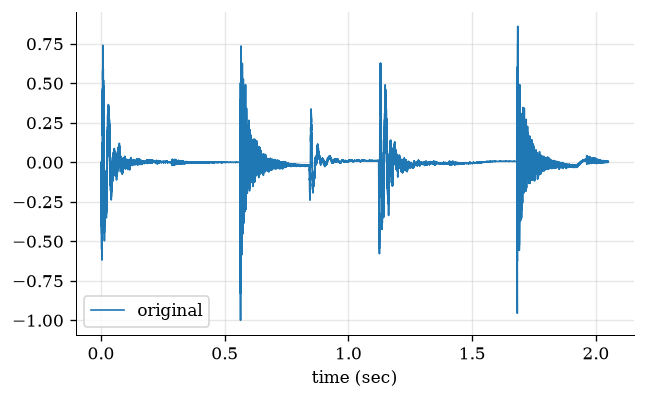

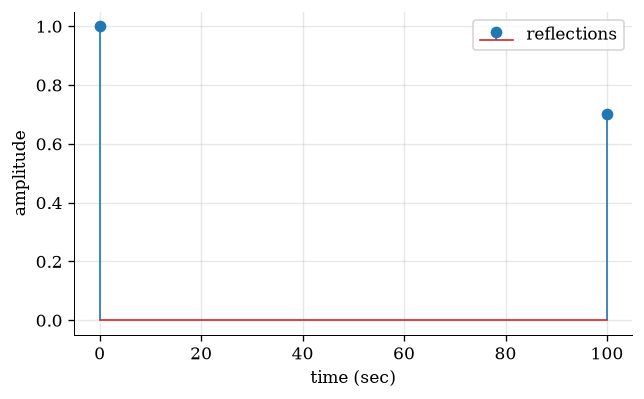

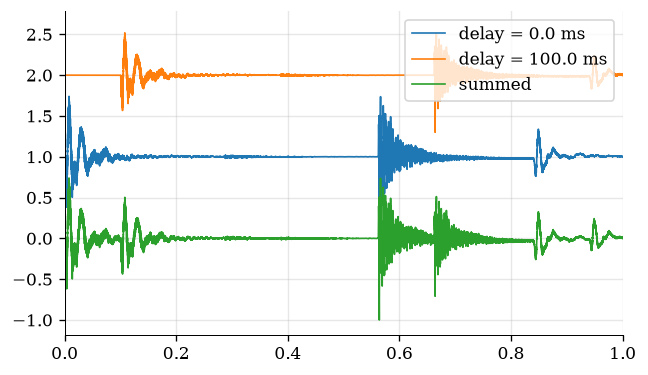

In [15]:
# define reverb configs (delays in ms)
reverb = {'gains':[1, 0.7], 'delays': [0, 100]} 
# reverb = {'gains':[1, 0.8, 0.6, 0.5, 0.4, 0.3], 'delays': [0, 11, 31, 43, 51, 75]} 

# load audio file
audio_in, fs = wavread('assets/drums.wav')

# play 
playsound(audio_in, fs)

# plot
t = np.arange(0, len(audio_in)) / fs
plt.plot(t, audio_in, label = 'original');
plt.xlabel('time (sec)'); plt.legend(); plt.show()

# plot
plt.stem(reverb['delays'], reverb['gains'], label = 'reflections');
plt.xlabel('time (sec)'); plt.ylabel('amplitude'); plt.legend(); plt.show()

# convert delays to number of samples
reverb["delays"] = [int(fs * x/1000) for x in reverb["delays"]]
max_delay_in_sample = np.max(reverb['delays'])

# init output
audio_out = np.zeros( len(audio_in) + max(reverb["delays"]) )
t = np.arange(0, len(audio_out)) / fs

# loop over tap delays
for i_tap in range(len(reverb["delays"])):

    # get delay and gain
    n = reverb["delays"][i_tap]
    g = reverb["gains"][i_tap]
    
    # create delayed audio tap
    audio_tap = g * np.pad(audio_in, (n, len(audio_out) - len(audio_in) - n))

    # plot
    plt.plot(t, audio_tap + i_tap + 1, label = f'delay = {1000*n/fs} ms')

    # add tap to output
    audio_out += audio_tap

# normalise output gain
audio_out /= max(1, np.max(np.abs(audio_out)))

# play 
playsound(audio_out, fs)

# plot
plt.plot(t, audio_out, label = 'summed');
plt.xlim([0, 1]); 
plt.legend(loc = 'upper right'); plt.show()

On aura tendance à s'inspirer des gains et des atténuations qu'on retrouve dans une salle réelle pour créer des réverb plus naturelles.
Pour les mesurer, on émet typiquement un son très court (e.g. coup de feu) dans cette salle.
Sur l'enregistrement de ce son, on retrouvera des pics d'énergie qui correspondent au son direct et aux réflexions successives du son dans la salle.

On appelle la réponse de la salle à cette "impulsion" sa **réponse impulsionnelle**.

## Créer une réverbération à partir d'une réponse impulsionnelle

Dans l'exemple ci-dessous, on utilise le contenu de 'ir_mono.wav', qui contient la réponse impulsionnelle d'une salle, pour créer la réverb.

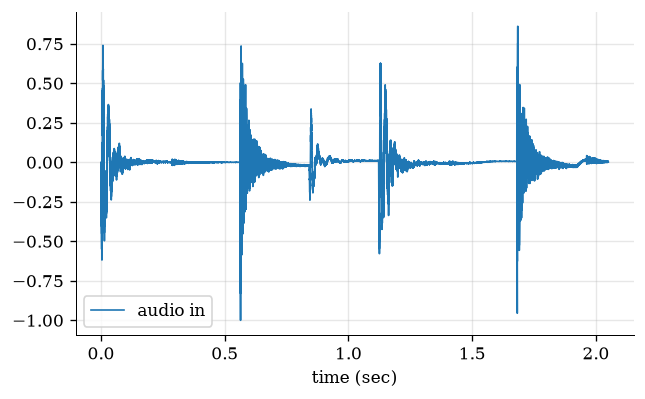

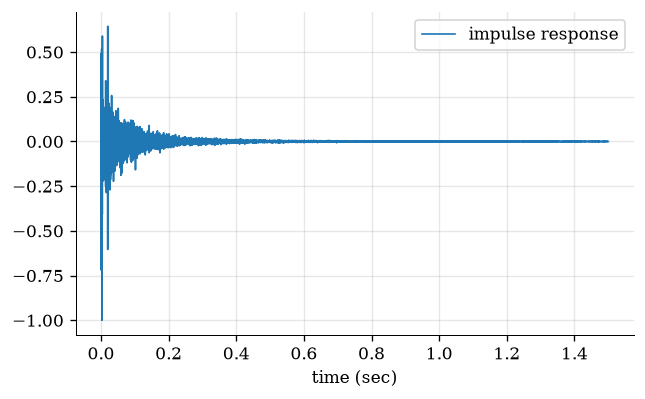

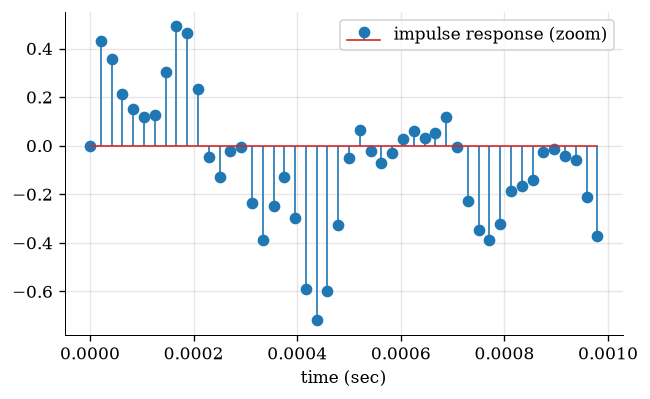

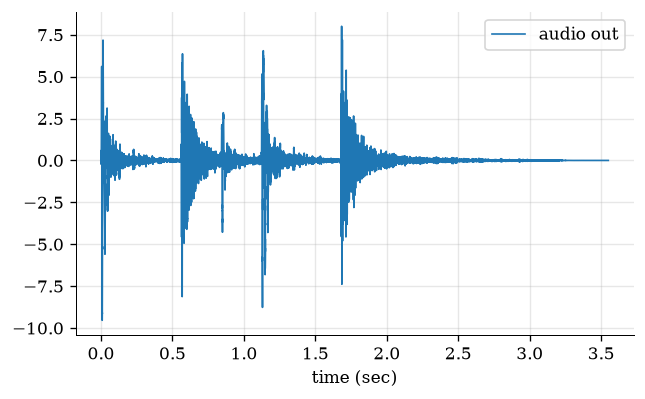

In [16]:
# load audio file
audio_in, fs = wavread('assets/drums.wav')

# play 
playsound(audio_in, fs)

# plot
t = np.arange(0, len(audio_in))/fs
plt.plot(t, audio_in, label = 'audio in'); 
plt.legend(); plt.xlabel('time (sec)'); plt.show()

# load impulse response
ir, fs = wavread('assets/ir_mono.wav')
ir = ir / np.max(np.abs(ir))

# play 
playsound(ir, fs)

# plot
t = np.arange(0, len(ir))/fs
plt.plot(t, ir, label = 'impulse response'); 
plt.legend(); plt.xlabel('time (sec)'); plt.show()
#
selvect = np.arange(0, int(0.001*fs))
t = np.arange(0, len(ir))/fs
plt.stem(t[selvect], ir[selvect], label = 'impulse response (zoom)'); 
plt.legend(); plt.xlabel('time (sec)'); plt.show()

# convolve
audio_out = np.convolve(audio_in, ir)

# play 
playsound(audio_out, fs)

# plot
t = np.arange(0, len(audio_out))/fs
plt.plot(t, audio_out, label = 'audio out'); 
plt.legend(); plt.xlabel('time (sec)'); plt.show()

Cette addition de versions retardées et atténuées du signal s'écrit, pour le signal x(n) et la réponse impulsionnelle h(n) : 

$ y(n) = h(0) . x(n) + h(1) . x(n-1) + ... + h(K) . x(n-K) $

$ y(n) = \sum_{k = 0}^{K} h(k) . x(n-k)$

$ y(n) = h(n) \circledast x(n) $

i.e. $y$ est la **convolution** entre $h$ et $x$.

$h$ dans cet exemple et le précédant est appelé une FIR ou **Finite Impulse Response**.

## Resources additionnelles

- 3Blue1Brown video: [But what is a convolution?](https://www.youtube.com/watch?v=KuXjwB4LzSA&)